# Data Preprocessing

In this notebook, I test the scalar `MinMaxScaler`. Other scalars are, for example, `StandardScaler`, `RobustScaler` and `Normalizer`.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [6]:
scaler = MinMaxScaler()

Feature scaling should be fitted using the **training set only** and then applied to the **test set** using the same transformation. Methods such as `MinMaxScaler` or `StandardScaler` compute parameters from the data (for example minimum and maximum values, or mean and standard deviation). If these parameters were estimated using the entire dataset before splitting, information from the test set would influence the preprocessing step, introducing **data leakage** and leading to overly optimistic estimates of model performance. The correct workflow is therefore to **fit the scaler on `X_train`** to learn the transformation parameters and then **apply the same transformation to both `X_train` and `X_test`**. This ensures that the test set remains an unbiased approximation of unseen future data and that the model evaluation reflects realistic generalization performance.

In [7]:
scaler.fit(X_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [8]:
X_train_scaled = scaler.transform(X_train)

In [9]:
X_test_scaled = scaler.transform(X_test)

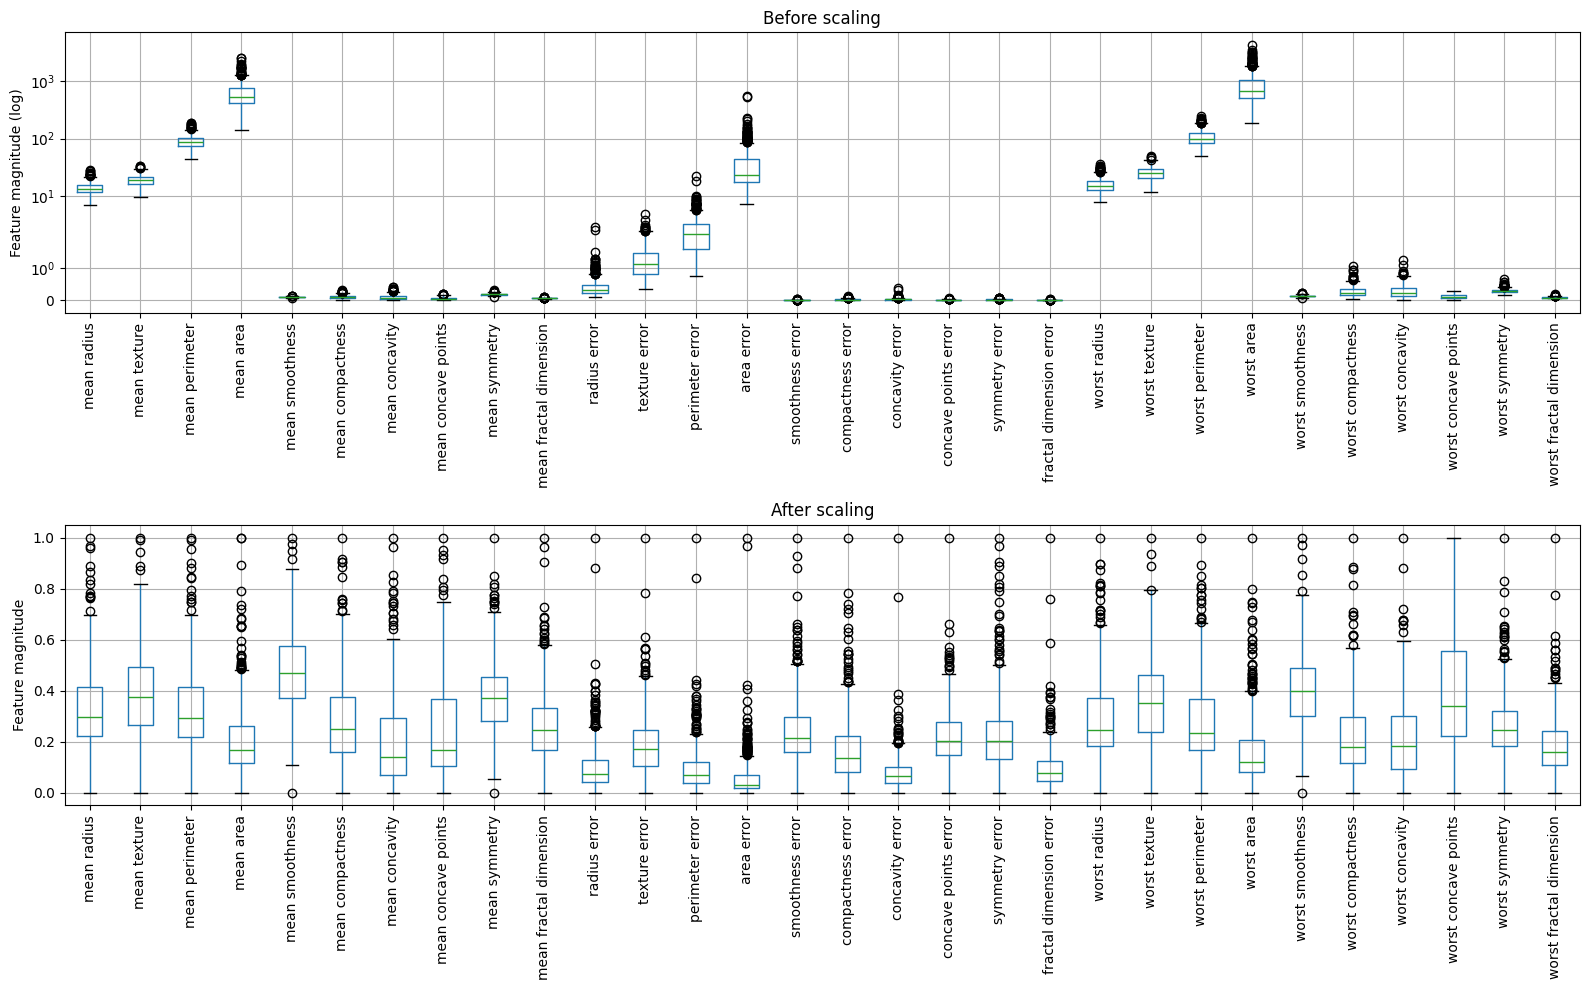

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

pd.DataFrame(X_train, columns=data.feature_names).boxplot(ax=axes[0], rot=90)
axes[0].set_yscale("symlog")
axes[0].set_ylabel("Feature magnitude (log)")
axes[0].set_title("Before scaling")

pd.DataFrame(X_train_scaled, columns=data.feature_names).boxplot(ax=axes[1], rot=90)
axes[1].set_ylabel("Feature magnitude")
axes[1].set_title("After scaling")

plt.tight_layout()
plt.show()